In [31]:
from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Project root directory
PROJECT_ROOT = Path.cwd().parent
DATABASE_PATH = PROJECT_ROOT / "database" / "shoppers.db"

# DB connection helper function, to avoid repeated code in notebook 
def run_query(query: str) -> pd.DataFrame:
    connection = sqlite3.connect(DATABASE_PATH)
    try:
        return pd.read_sql_query(query, connection)
    finally:
        connection.close()

# Digital Customer Journey Analysis

## 1. Business Question

This project analyses online customer sessions to understand which
visitor characteristics, traffic sources and engagement behaviours
are associated with conversion.

The analysis aims to answer:

- What is the overall website conversion rate?
- Do new and returning visitors convert differently?
- How does conversion vary by traffic source?
- Does conversion vary over time?
- Are there meaningful differences between customer segments?
- What insights could inform improvements to the digital customer journey?

## 2. Dataset & Methodology

The analysis uses the UCI Online Shoppers Purchasing Intention dataset,
which contains session-level information about visitors to an online
shopping website.

The dataset contains behavioural, technical and traffic-related
variables, with `Revenue` indicating whether the session resulted in a
purchase.

### Tools

- SQLite — data aggregation and segmentation
- Python — analysis
- pandas — data manipulation
- matplotlib (& seaborn) — visualisation
- scipy — statistical analysis 

### Approach

The analysis progresses from overall conversion performance to visitor and traffic-source comparisons, followed by segmentation and statistical analysis.

Data loaded via load_data.py; full script in the project repository.

## 3. Data Quality

Before analysing the data, I checked:

- Dataset dimensions
- Data types
- Missing values
- Duplicate records
- Categorical values
- Numerical ranges
- Revenue/conversion values
- Time periods represented


In [32]:
#Print out some basic information about the dataset
df = pd.read_csv("../data/online_shoppers_intention.csv")

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"Missing values: {df.isna().sum().sum():,}")
print(f"Duplicate rows: {df.duplicated().sum():,}")

Rows: 12,330
Columns: 18
Missing values: 0
Duplicate rows: 125


Data also inspected via (test.sql and data_quality.py): script in project repository.

### Data Quality Findings

The dataset contains 12,330 sessions and 18 variables.

No missing values were identified.

### Duplicate Records

In the following cells I want to inspect the duplicate rows to explore further.

**125 exact duplicate rows** were identified (201 rows in total when
including the first occurrence of each duplicated combination).

Because the dataset represents individual website sessions with no
customer identifier available, identical rows cannot automatically be
assumed to be errors — two different visitors could possibly produce
the same recorded values, particularly for short, low-engagement
sessions.

All 201 of these rows shared a highly uniform profile: no
administrative or informational page visits, one (occasionally two)
product-related page views and `PageValues` of 0.
All duplicate rows contained `BounceRates` and `ExitRates` of exactly 0.2
though this value appears elsewhere in the dataset an not just the 
duplicates. 

None were associated with a completed purchase (`Revenue = False` in all 201 cases).

Across the full dataset, 700 sessions (5.68%) share this same
`BounceRates` value of 0.2, and these sessions convert at just 0.43% —
far below the 15.47% dataset average. This supports the interpretation
that 0.2 possibly represents a value assigned to minimal-engagement
sessions by the analytics platform.

Since none of the duplicate rows are associated with a conversion,
retaining them does not risk increasing the conversion rate. For this
reason, the duplicates have been retained rather than removed. 

No additional cleaning was required for the variables used in this
analysis.

<details>
<summary><strong>Show supporting analysis</strong></summary>

The cells below show the investigation behind this finding.

</details>

#### Supporting analysis

In [33]:
# Inspect some duplicate rows
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(20)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
8247,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
10751,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
11658,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
8882,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11934,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11110,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
12159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
10341,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11801,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11938,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False


In [34]:
# Do any duplicate rows lead to conversion?
duplicate_count = df[df.duplicated(keep=False)]["Revenue"].sum()
print(f"Duplicate rows with Revenue = True: {duplicate_count}")

Duplicate rows with Revenue = True: 0


In [35]:
#Noticing Bounce/Exit Rates were 0.2, what types of pages were visited? 
duplicates = df[df.duplicated(keep=False)]

print(duplicates[["Administrative", "Informational", "ProductRelated", "BounceRates", "ExitRates", "PageValues"]].describe())

       Administrative  Informational  ProductRelated  BounceRates  ExitRates  \
count           201.0          201.0      201.000000        201.0      201.0   
mean              0.0            0.0        1.059701          0.2        0.2   
std               0.0            0.0        0.237525          0.0        0.0   
min               0.0            0.0        1.000000          0.2        0.2   
25%               0.0            0.0        1.000000          0.2        0.2   
50%               0.0            0.0        1.000000          0.2        0.2   
75%               0.0            0.0        1.000000          0.2        0.2   
max               0.0            0.0        2.000000          0.2        0.2   

       PageValues  
count       201.0  
mean          0.0  
std           0.0  
min           0.0  
25%           0.0  
50%           0.0  
75%           0.0  
max           0.0  


In [36]:
comparison = pd.DataFrame({
    "Duplicates": duplicates.select_dtypes(
        include="number"
    ).mean(),
    "Full Dataset": df.select_dtypes(
        include="number"
    ).mean()
})

comparison

,Duplicates,Full Dataset
Administrative,0.000000,2.315166
Administrative_Duration,0.000000,80.818611
Informational,0.000000,0.503569
Informational_Duration,0.000000,34.472398
ProductRelated,1.059701,31.731468
ProductRelated_Duration,0.000000,1194.746220
BounceRates,0.200000,0.022191
ExitRates,0.200000,0.043073
PageValues,0.000000,5.889258
SpecialDay,0.013930,0.061427


How many other sessions had BounceRate as 0.2? Is this common, or possibly a value for a certain type of session that's undocumented?

In [37]:
bounce_02 = df[df["BounceRates"] == 0.2]

print("Sessions with BounceRate = 0.2:", len(bounce_02))
print("Conversions:", bounce_02["Revenue"].sum())
print("Conversion rate:", bounce_02["Revenue"].mean())

Sessions with BounceRate = 0.2: 700
Conversions: 3
Conversion rate: 0.004285714285714286


In [38]:
conversion_comparison = pd.DataFrame({
    "Sessions": [
        len(bounce_02),
        len(df)
    ],
    "Conversions": [
        bounce_02["Revenue"].sum(),
        df["Revenue"].sum()
    ],
    "Conversion Rate": [
        bounce_02["Revenue"].mean(),
        df["Revenue"].mean()
    ]
}, index=[
    "BounceRate = 0.2",
    "Full Dataset"
])

conversion_comparison

,Sessions,Conversions,Conversion Rate
BounceRate = 0.2,700,3,0.004286
Full Dataset,12330,1908,0.154745


## 4. Overall Conversion

### Business Question

What proportion of website sessions result in a purchase?

This provides the baseline conversion rate against which different
visitor groups and traffic sources can be compared.

In [39]:
# SQL query
query = """
SELECT
    COUNT(*) AS total_sessions,
    SUM(CASE WHEN Revenue = 1 THEN 1 ELSE 0 END) AS conversions,
    ROUND(
        100.0 * SUM(CASE WHEN Revenue = 1 THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS conversion_rate_percent
FROM sessions;
"""

# Run query and return result as a DataFrame
conversion_summary = run_query(query)
conversion_summary

,total_sessions,conversions,conversion_rate_percent
0,12330,1908,15.47


In [40]:
conversion_rate = conversion_summary.loc[
    0, "conversion_rate_percent"
]

print(f"Overall conversion rate: {conversion_rate:.2f}%")

Overall conversion rate: 15.47%


In [41]:
conversion_counts = pd.DataFrame({
    "Outcome": ["Converted", "Did not convert"],
    "Sessions": [
        conversion_summary.loc[0, "conversions"],
        conversion_summary.loc[0, "total_sessions"]
        - conversion_summary.loc[0, "conversions"]
    ]
})



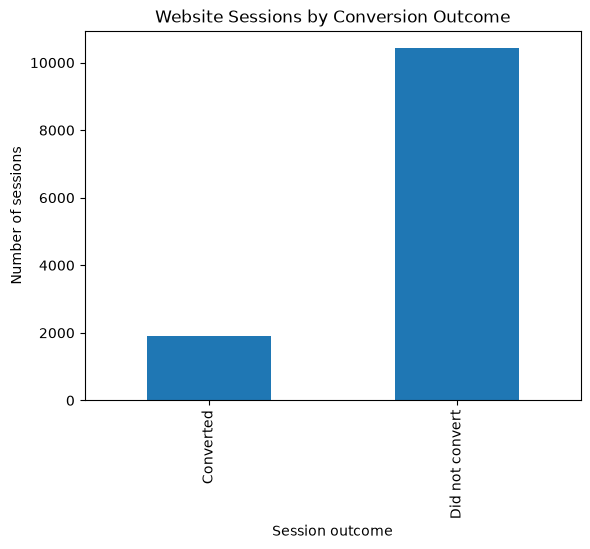

In [42]:
conversion_counts.plot(
    x="Outcome",
    y="Sessions",
    kind="bar",
    legend=False,
    title="Website Sessions by Conversion Outcome",
    xlabel="Session outcome",
    ylabel="Number of sessions"
);

### Interpretation

**The overall conversion rate for this dataset is 15.47%**

The overall conversion rate provides a baseline against which the
performance of different visitor segments and traffic sources can be
compared.

The next stage of the analysis investigates whether conversion differs
between new and returning visitors and across different traffic sources.

## 5. Visitor Type Analysis

### Business Question

Do new and returning visitors have different conversion rates?

In [43]:
# SQL query
query = """
SELECT
    VisitorType,
    COUNT(*) AS sessions,
    SUM(CASE WHEN Revenue = 1 THEN 1 ELSE 0 END) AS conversions,
    ROUND(
        100.0 * SUM(CASE WHEN Revenue = 1 THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS conversion_rate_percent
FROM sessions
GROUP BY VisitorType
ORDER BY conversion_rate_percent DESC;
"""

# Run query and return result as a DataFrame
vtc_summary = run_query(query)
vtc_summary


,VisitorType,sessions,conversions,conversion_rate_percent
0,New_Visitor,1694,422,24.91
1,Other,85,16,18.82
2,Returning_Visitor,10551,1470,13.93


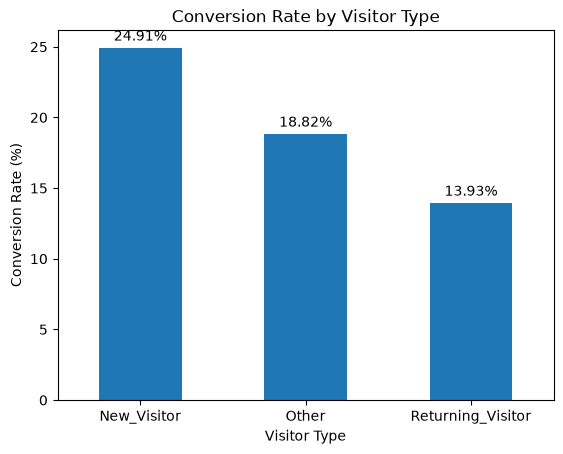

In [44]:
ax = vtc_summary.plot(
    x="VisitorType",
    y="conversion_rate_percent",
    kind="bar",
    legend=False,
    title="Conversion Rate by Visitor Type",
    xlabel="Visitor Type",
    ylabel="Conversion Rate (%)"
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

### Interpretation

New visitors had the highest conversion rate at 24.91%, compared with 
13.93% for returning visitors. This represents a difference of 10.98 percentage 
points, with new visitors converting at approximately 1.8 times the rate of 
returning visitors. The "Other" visitor group had a conversion rate of 18.82%, 
although this group contained only 85 sessions and therefore represents a 
relatively small sample. 

While the results show a clear difference in conversion behaviour between visitor types, 
they do not establish that visitor type itself causes the difference.

Despite their higher conversion rate, new visitors accounted for only 1,694 sessions, 
compared with 10,551 returning visitor sessions. Returning visitors therefore generated 
substantially more conversions in absolute terms (1,470 compared with 422), 
despite their lower conversion rate.

## 6. Visitor and Traffic Type Segmentation

### Business Question

Does the relationship between traffic source and conversion differ by visitor type?

To avoid over-interpreting conversion rates based on very small
sample sizes, the tables and visualisations are restricted to visitor/traffic
segments containing at least 50 sessions.

In [45]:

query = """
WITH agg AS (
    SELECT
        VisitorType,
        TrafficType,
        COUNT(*) AS sessions,
        SUM(CASE WHEN Revenue = 1 THEN 1 ELSE 0 END) AS conversions
    FROM sessions
    GROUP BY VisitorType, TrafficType
    HAVING COUNT(*) >= 50
)
SELECT
    VisitorType,
    TrafficType,
    sessions,
    conversions,
    ROUND(100.0 * conversions / sessions, 2) AS conversion_rate_percent
FROM agg
ORDER BY VisitorType, conversion_rate_percent DESC;
"""

segmentation_summary = run_query(query)


segmentation_summary

,VisitorType,TrafficType,sessions,conversions,conversion_rate_percent
0,New_Visitor,4,99,33,33.33
1,New_Visitor,8,175,50,28.57
2,New_Visitor,5,149,39,26.17
3,New_Visitor,2,936,238,25.43
4,New_Visitor,3,140,25,17.86
5,New_Visitor,11,51,6,11.76
6,Other,20,52,14,26.92
7,Returning_Visitor,8,167,45,26.95
8,Returning_Visitor,20,129,29,22.48
9,Returning_Visitor,11,195,41,21.03


In [46]:
segmentation_pivot = segmentation_summary.pivot(
    index="TrafficType",
    columns="VisitorType",
    values="conversion_rate_percent"
)

segmentation_pivot

VisitorType,New_Visitor,Other,Returning_Visitor
TrafficType,,,
1,NaN,NaN,10.59
2,25.43,NaN,20.50
3,17.86,NaN,8.08
4,33.33,NaN,13.61
5,26.17,NaN,15.45
6,NaN,NaN,10.47
8,28.57,NaN,26.95
10,NaN,NaN,20.00
11,11.76,NaN,21.03


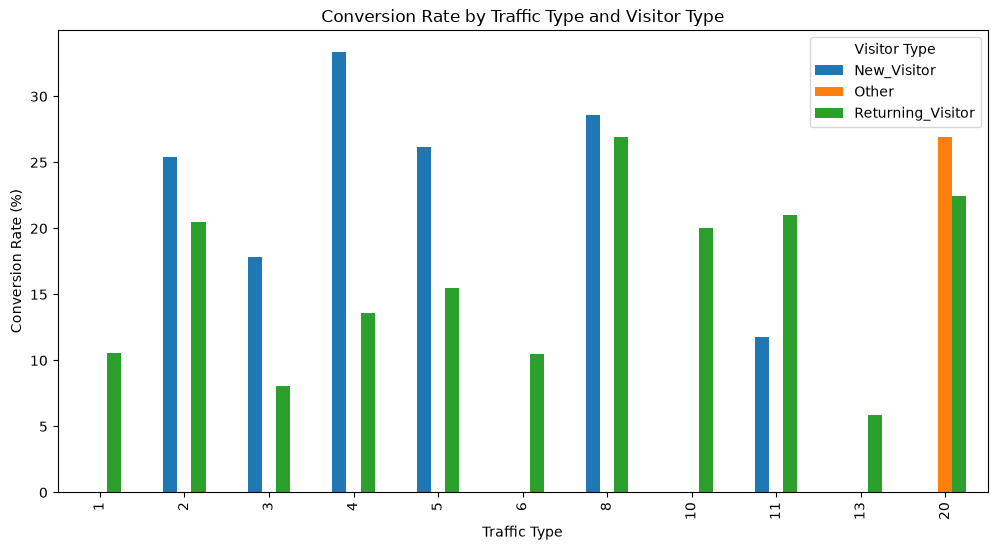

In [47]:
ax = segmentation_pivot.plot(
    kind="bar",
    figsize=(12, 6),
    title="Conversion Rate by Traffic Type and Visitor Type",
    xlabel="Traffic Type",
    ylabel="Conversion Rate (%)"
)

ax.legend(title="Visitor Type")

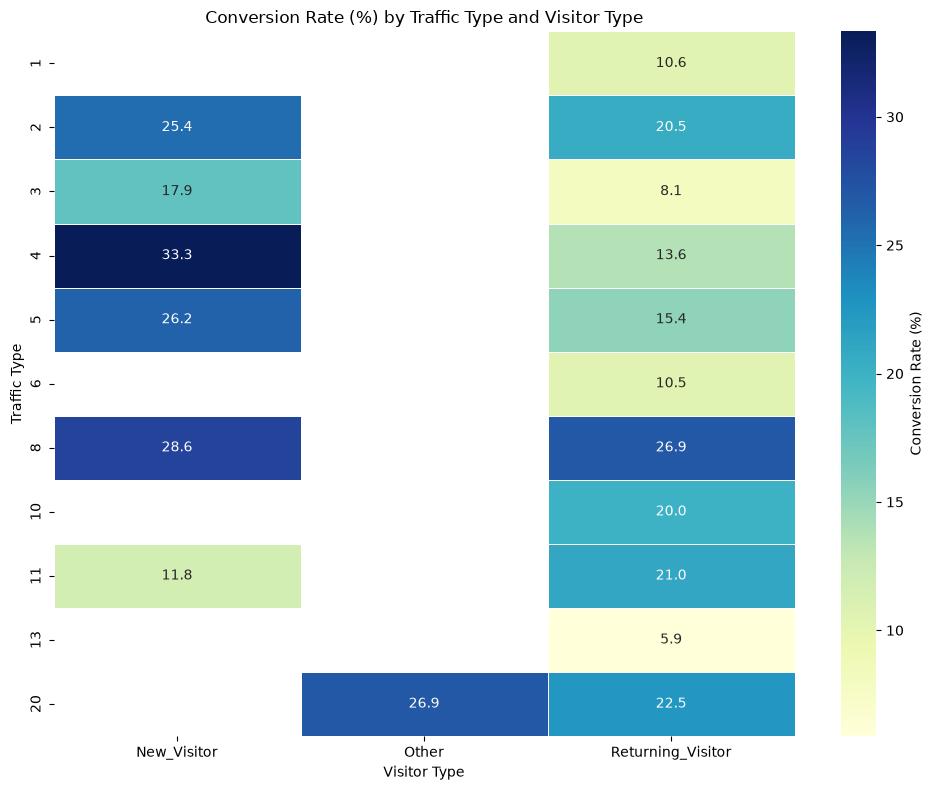

In [48]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    segmentation_pivot,
    annot=True,          # show the actual numbers in each cell
    fmt=".1f",           # format numbers to 1 decimal place
    cmap="YlGnBu",       # colour scale: light = low, dark = high
    cbar_kws={"label": "Conversion Rate (%)"},
    linewidths=0.5,      # thin gridlines between cells
)

plt.title("Conversion Rate (%) by Traffic Type and Visitor Type")
plt.xlabel("Visitor Type")
plt.ylabel("Traffic Type")
plt.tight_layout()
plt.show()

### Interpretation
Among segments with at least 50 session, the segmentation analysis reveals a notable difference in conversion performance between new and returning visitors across several traffic sources. Where the same traffic source appears for both visitor types, new visitors generally have a higher conversion rate e.g. Traffic Type 4 has a conversion rate of 33.33% among new visitors compared with 10.59% among returning visitors, while Traffic Type 5 shows a difference of 26.17% versus 15.45%.

There is also considerable variation in conversion rates between traffic sources, particularly among returning visitors. Returning visitor conversion rates range from 5.88% for Traffic Type 13 to 26.95% for Traffic Type 8. This suggests that traffic source may be associated with substantially different levels of conversion performance within the returning visitor population.

Traffic types vary considerably in number of sessions and may represent different underlying customer characteristics. Further investigation would be required to understand why some traffic sources perform differently.

Overall, the analysis suggests that visitor type and traffic source are both useful dimensions for segmenting conversion behaviour. The same traffic sources perform differently depending on visitor type, suggesting that traffic source and visitor type should be considered together when assessing channel performance.

## 7. Monthly Conversion Analysis

### Business Question

Does conversion performance vary over time?

Monthly conversion rates are compared to identify potential seasonal patterns or periods of unusually high or low conversion.

In [49]:

# SQL query
query = """
SELECT
    Month,
    COUNT(*) AS sessions,
    SUM(CASE WHEN Revenue = 1 THEN 1 ELSE 0 END) AS conversions,
    ROUND(
        100.0 * SUM(CASE WHEN Revenue = 1 THEN 1 ELSE 0 END) / COUNT(*), 
        2
    ) AS conversion_rate_percent
FROM sessions
GROUP BY Month
"""

# Run query and return result as a DataFrame
monthly_conversion_summary = run_query(query)

monthly_conversion_summary

,Month,sessions,conversions,conversion_rate_percent
0,Aug,433,76,17.55
1,Dec,1727,216,12.51
2,Feb,184,3,1.63
3,Jul,432,66,15.28
4,June,288,29,10.07
5,Mar,1907,192,10.07
6,May,3364,365,10.85
7,Nov,2998,760,25.35
8,Oct,549,115,20.95
9,Sep,448,86,19.20


### Monthly ordering

The dataset's months are categorical rather than chronological, so the
results are explicitly ordered from January to December before plotting.

In [50]:
# Sort the DataFrame by month order for graphical representation
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "June",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

monthly_conversion_summary["Month"] = pd.Categorical(
    monthly_conversion_summary["Month"],
    categories=month_order,
    ordered=True
)

monthly_conversion_summary = (
    monthly_conversion_summary
    .sort_values("Month")
    .reset_index(drop=True)
)

monthly_conversion_summary

,Month,sessions,conversions,conversion_rate_percent
0,Feb,184,3,1.63
1,Mar,1907,192,10.07
2,May,3364,365,10.85
3,June,288,29,10.07
4,Jul,432,66,15.28
5,Aug,433,76,17.55
6,Sep,448,86,19.20
7,Oct,549,115,20.95
8,Nov,2998,760,25.35
9,Dec,1727,216,12.51


[Text(0, 0, 'Feb'),
 Text(1, 0, 'Mar'),
 Text(2, 0, 'May'),
 Text(3, 0, 'June'),
 Text(4, 0, 'Jul'),
 Text(5, 0, 'Aug'),
 Text(6, 0, 'Sep'),
 Text(7, 0, 'Oct'),
 Text(8, 0, 'Nov'),
 Text(9, 0, 'Dec')]

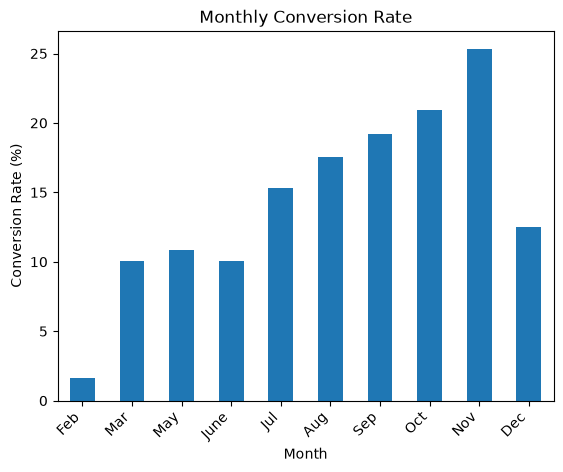

In [51]:
ax = monthly_conversion_summary.plot(
    x="Month",
    y="conversion_rate_percent",
    kind="bar",
    legend=False,
    title="Monthly Conversion Rate",
    xlabel="Month",
    ylabel="Conversion Rate (%)"
)

ax.set_xticks(range(len(monthly_conversion_summary)))
ax.set_xticklabels(
    monthly_conversion_summary["Month"],
    rotation=45,
    ha="right"
)

### Interpretation

There is a general trend of increasing Conversion Rate from July -> November. November stands out, with both the highest conversion rate (**25.35%**) and the second-highest session volume (2,998 sessions) — possibly consistent with Black Friday/Cyber Monday shopping activity. 

There is then a sudden drop in Conversion Rate going into December vs November (12.51% vs 25.35%).

February is the clear low point (1.63%), though this is based on a much smaller sample (184 sessions). 

Furthermore, the dataset does not include January or April, which limits the ability to draw a complete annual picture.



## 8. Weekday vs Weekend Conversion

### Business Question

Does conversion rate differ between weekday and weekend sessions, and
does this vary by visitor type?

We're aware only 'Other' + 'Weekend' traffic has a count below 50, so ignored the small sample size for this one query.

In [ ]:
query = """
WITH agg AS (
    SELECT
        VisitorType,
        Weekend,
        COUNT(*) AS sessions,
        SUM(CASE WHEN Revenue = 1 THEN 1 ELSE 0 END) AS conversions
    FROM sessions
    GROUP BY VisitorType, Weekend
   
)
SELECT
    VisitorType,
    Weekend,
    sessions,
    conversions,
    ROUND(100.0 * conversions / sessions, 2) AS conversion_rate_percent
FROM agg
ORDER BY VisitorType, conversion_rate_percent DESC;
"""

weekend_summary = run_query(query)
weekend_summary

,VisitorType,Weekend,sessions,conversions,conversion_rate_percent
0,New_Visitor,0,1215,317,26.09
1,New_Visitor,1,479,105,21.92
2,Other,0,78,15,19.23
3,Other,1,7,1,14.29
4,Returning_Visitor,1,2382,393,16.50
5,Returning_Visitor,0,8169,1077,13.18


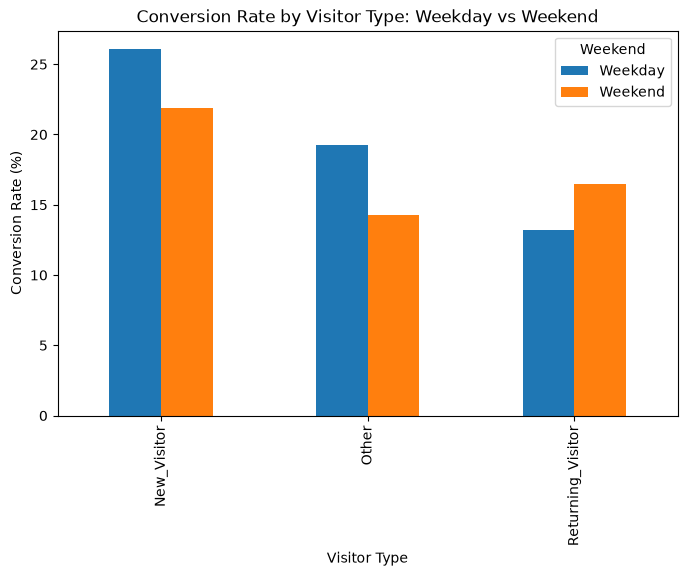

In [53]:
weekend_pivot = weekend_summary.pivot(
    index="VisitorType",
    columns="Weekend",
    values="conversion_rate_percent"
)

ax = weekend_pivot.plot(
    kind="bar",
    figsize=(8, 5),
    title="Conversion Rate by Visitor Type: Weekday vs Weekend",
    xlabel="Visitor Type",
    ylabel="Conversion Rate (%)"
)
ax.legend(title="Weekend", labels=["Weekday", "Weekend"])

### Interpretation

The weekday/weekend pattern reverses direction depending on visitor
type:

New visitors convert better on weekdays (26.09%) than weekends (21.92%)

Returning visitors convert better on weekends (16.50%) than weekdays (13.18%)

These figures are consistent with the overall visitor-type conversion
rates in Section 5 where the overall rate for each visitor type sits
between its weekday and weekend rates, weighted by the higher volume
of weekday sessions.



## 9. Statistical Analysis

### Business Question
   
   Are the associations observed between visitor type, traffic source,
   and weekend timing statistically significant? 

   A stricter 0.01 threshold was used given the large sample sizes.

In [54]:
#Create function to run chi-square test for independence on our dataframe
def run_chi_square(df: pd.DataFrame, column: str, target: str = "Revenue") -> None:
    contingency_table = pd.crosstab(df[column], df[target])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print(f"Chi-square test: {column} vs {target}")
    print(f"  Chi2 statistic: {chi2:.2f}")
    print(f"  Degrees of freedom: {dof}")
    print(f"  p-value: {p_value:.10f}")

    if p_value < 0.01:
        print(f"  Result: statistically significant association (p < 0.01). Strong evidence to reject the null hypothesis of independence.")
    else:
        print(f"  Result: no statistically significant association (p >= 0.01). Insufficient evidence to reject the null hypothesis of independence.")
    print()

In [56]:
# Associations between categorical variables and Revenue (i.e. 2 tests)
# Will check Traffic Type values before running Chi-Square test on that for a 3rd test.
for column in ["VisitorType", "Weekend"]:
    run_chi_square(df, column)

Chi-square test: VisitorType vs Revenue
  Chi2 statistic: 135.25
  Degrees of freedom: 2
  p-value: 0.0000000000
  Result: statistically significant association (p < 0.01). Strong evidence to reject the null hypothesis of independence.

Chi-square test: Weekend vs Revenue
  Chi2 statistic: 10.39
  Degrees of freedom: 1
  p-value: 0.0012663251
  Result: statistically significant association (p < 0.01). Strong evidence to reject the null hypothesis of independence.



The general chi-square test found a significant association between 
Weekend and Revenue, but the descriptive segmentation (Section 8) showed 
the direction of the weekday/weekend gap reversing between new and 
returning visitors — new visitors converted better on weekdays, returning 
visitors better on weekends. 
Because of the unexplained reversal in this subgroup, I will re-run the 
test separately within each visitor type to check whether the aggregate result 
was being driven by one group. 

In [58]:
# Interaction: does the Weekend effect differ by VisitorType?
#This is conducted because the trend/pattern reverses for different types of visitor.
print("Weekend effect on Revenue, tested separately per VisitorType:\n")

for visitor_type in df["VisitorType"].unique():
    subset = df[df["VisitorType"] == visitor_type]
    print(f"--- {visitor_type} (n={len(subset)}) ---")
    run_chi_square(subset, "Weekend")

Weekend effect on Revenue, tested separately per VisitorType:

--- Returning_Visitor (n=10551) ---
Chi-square test: Weekend vs Revenue
  Chi2 statistic: 16.62
  Degrees of freedom: 1
  p-value: 0.0000455832
  Result: statistically significant association (p < 0.01). Strong evidence to reject the null hypothesis of independence.

--- New_Visitor (n=1694) ---
Chi-square test: Weekend vs Revenue
  Chi2 statistic: 2.97
  Degrees of freedom: 1
  p-value: 0.0845866373
  Result: no statistically significant association (p >= 0.01). Insufficient evidence to reject the null hypothesis of independence.

--- Other (n=85) ---
Chi-square test: Weekend vs Revenue
  Chi2 statistic: 0.00
  Degrees of freedom: 1
  p-value: 1.0000000000
  Result: no statistically significant association (p >= 0.01). Insufficient evidence to reject the null hypothesis of independence.



In [57]:
#Traffic Type has some values with very low counts, so we will filter those out before running the Chi-Square test.
traffic_counts = df["TrafficType"].value_counts()
valid_traffic_types = traffic_counts[traffic_counts >= 50].index

df_filtered = df[df["TrafficType"].isin(valid_traffic_types)]
run_chi_square(df_filtered, "TrafficType")

Chi-square test: TrafficType vs Revenue
  Chi2 statistic: 353.61
  Degrees of freedom: 10
  p-value: 0.0000000000
  Result: statistically significant association (p < 0.01). Strong evidence to reject the null hypothesis of independence.



### Interpretation

**VisitorType and Revenue**: chi2 = 135.25, dof = 2, p < 0.001. A
statistically significant association was found, consistent with the 
difference observed between new and returning visitor conversion rates.



**Weekend and Revenue**: chi2 = 10.39, dof = 1, p = 0.0013. This
reached statistical significance, therefore evidence suggests an association
between Weekend and Revenue for these data. As seen earlier, the aggregate Weekend 
effect was driven almost entirely by returning visitors but vanished when 
new visitors were tested separately.


**TrafficType and Revenue**
Before running the chi-square test on 'TrafficType', expected cell counts were checked for
an expected count below 5. This was driven by traffic types with very few observations 
e.g. TrafficTypes 12 and 17 each contained only one session. The analysis was therefore 
repeated after restricting the test to traffic types with at least 50 sessions, consistent 
with the minimum threshold used in the segmentation analysis. Following this restriction, 
the expected-count criterion was satisfied, allowing the resulting chi-square statistic 
and p-value to be interpreted.
The result remained highly significant (chi2 = 353.61, dof = 10, p < 0.001) indicating
strong evidence to suggest an association between Traffic Type and Revenue.

## 10. Key Findings


- Overall, 1,908 of 12,330 sessions resulted in a conversion, giving 
  an overall conversion rate of **15.47%**. This provides the baseline 
  against which subsequent segment performance can be compared.
- **New visitors converted at approximately 1.8 times the rate of 
  returning visitors** (24.91% vs 13.93%). A chi-square test provided 
  strong evidence of an association between visitor type and conversion 
  (p < 0.001).
- Conversion rate varied considerably by **traffic source**, ranging
  from 33.33% (New_Visitor, TrafficType 4) down to 5.88%
  (Returning_Visitor, TrafficType 13) among segments with at least 50
  sessions. These differences highlight potentially important 
  segment-level variation, although they do not establish that traffic 
  source itself causes differences in conversion.
- **November** had both the highest monthly conversion rate (25.35%)
  and high session volume. This warrants further investigation 
  alongside seasonal or promotional activity (e.g. Black Friday/Cyber
  Monday), although the available data cannot establish a specific cause. 
  December, converted notably lower (12.51%).
- The **weekday/weekend pattern reverses by visitor type**: new
  visitors converted at a higher rate on weekdays, returning visitors 
  converted at a higher rate on weekends — though only the 
  returning-visitor pattern is statistically significant. 
- **125 duplicate rows** were identified. These records shared a 
  distinctive low-engagement pattern, including BounceRate and ExitRate 
  values of 0.2, and did not result in conversions. Their characteristics 
  suggest they may represent a particular type of low-engagement session, 
  but the dataset does not establish that 0.2 is a default analytics 
  value. The records were therefore retained rather than removed, with no 
  material impact on the overall conversion analysis.

## 11. Recommendations

- **Investigate why returning visitors convert at a notably lower rate
  than new visitors.** The gap is large and consistent enough to be
  worth exploring further e.g. through site search behaviour, user 
  research etc. rather than assumed to be expected.

- **Treat traffic-source conversion differences as a starting point for
  further investigation when considering budget allocation.**
  Conversion rate alone doesn't account for cost, volume, or margin per
  channel. Combining these findings with marketing spend data would be
  needed before drawing conclusions about where to prioritise.

- **Explore what may explain the November conversion peak.** 
  Potentially seasonal demand, promotional activity, or another factor
  not captured in this dataset. A single year of data cannot confirm
  whether this is a recurring pattern.

- **Treat the weekday/weekend difference by visitor type as a
  hypothesis for new visitors specifically.** 
  This pattern was statistically significant for returning visitors
  only; the apparent new-visitor difference did not reach significance
  and may reflect sampling variation.

- **Request a mapping** for 'TrafficType', 'OperatingSystems', 'Browser'
  and 'Region' codes from the data owner, to allow the traffic-source
  findings to be interpreted against real-world channels.

## 12. Limitations


- **No customer identifier is available.** Sessions cannot be linked
  to individual customers over time, so it is not possible to
  distinguish a single frequent visitor's repeated behaviour from
  genuinely different visitors. This also affects how duplicate rows
  can be interpreted (see Data Quality section).
- **Incomplete year coverage.** The dataset does not include January
  or April, and covers only a single year overall, so apparent
  seasonal patterns (e.g. monthly conversion differences) cannot be
  confirmed as a recurring yearly pattern versus a one-off
  characteristic of that particular year.
- **Unlabelled categorical codes.** `TrafficType`, `OperatingSystems`,
  `Browser`, and `Region` are represented as numeric codes with no
  published mapping to real-world categories (e.g. which code
  corresponds to "organic search" or "paid social" etc). This limits how
  actionable the traffic-source findings can be without further
  context from the original data owner.
- **Session-level, not customer-level, data.** The dataset captures
  what happened in a session, not why — it does not include
  information on price, product catalogue, marketing spend, or other
  business context that would help fully explain the patterns
  observed.
- **Statistical significance vs. practical significance.** As noted
  in Section 9, the large sample size means small differences can
  register as statistically significant without necessarily being
  commercially meaningful — findings should be read alongside the
  actual conversion-rate percentages, not p-values alone.
- **Strength of associations not calculated.** Cramér's V could be 
  calculated for all statistically significant Chi Square associations 
  in order to establish how strong these associations are. 
